In [ ]:
# IPL Exploratory Data Analysis

##This project analyzes IPL datasets to uncover insights about teams, players, venues, and match trends.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")


In [ ]:
### Importing Core Libraries
##We import the main libraries required for IPL data analysis:
##- **pandas** → for handling and analyzing datasets  
##- **matplotlib.pyplot** → for creating plots and charts  
##- **seaborn** → for advanced visualizations with built‑in themes  

##We also set Seaborn’s style to `"darkgrid"` to make our plots look cleaner and more professional.


In [3]:
import openpyxl
print("openpyxl installed successfully!")


openpyxl installed successfully!


In [ ]:
### Checking Excel Support
##We import the `openpyxl` library to ensure pandas can read Excel files.  
##The confirmation message shows that `openpyxl` is installed successfully and ready for use in our analysis.


In [4]:
players = pd.read_excel("Players.xlsx")
print(players.head())


      Player_Name        DOB Batting_Hand         Bowling_Skill Country
0  A Ashish Reddy 1991-02-24   Right_Hand      Right-arm medium   India
1      A Chandila 1983-12-05   Right_Hand    Right-arm offbreak   India
2        A Chopra 1977-09-19   Right_Hand    Right-arm offbreak   India
3     A Choudhary        NaT   Right_hand  Left-arm fast-medium     NaN
4     A Dananjaya        NaT   Right_Hand    Right-arm offbreak     NaN


In [ ]:
### Loading Player Data
##We load the `Players.xlsx` file using pandas with the `openpyxl` engine.  
##The `head()` function displays the first five rows of the dataset, giving us a quick preview of the player information and confirming that the file was read successfully.


In [6]:
matches = pd.read_csv("matches.csv")
players = pd.read_excel("Players.xlsx")
runs = pd.read_csv("most_runs_average_strikerate.csv")
teams = pd.read_csv("teams.csv")
home_away = pd.read_csv("teamwise_home_and_away.csv")

print(matches.shape, players.shape, runs.shape, teams.shape, home_away.shape)
print(runs.head())
print(home_away.head())

(756, 18) (566, 5) (516, 6) (15, 1) (14, 7)
     batsman  total_runs  out  numberofballs    average  strikerate
0    V Kohli        5426  152           4111  35.697368  131.987351
1   SK Raina        5386  160           3916  33.662500  137.538304
2  RG Sharma        4902  161           3742  30.447205  130.999466
3  DA Warner        4717  114           3292  41.377193  143.286756
4   S Dhawan        4601  137           3665  33.583942  125.538881
                     team  home_wins  away_wins  home_matches  away_matches  \
0  Rising Pune Supergiant          5          5             8             8   
1          Mumbai Indians         58         51           101            86   
2     Chennai Super Kings         51         49            89            75   
3          Delhi Capitals          3          7             6            10   
4     Sunrisers Hyderabad         30         28            63            45   

   home_win_percentage  away_win_percentage  
0            62.500000     

In [ ]:
### Loading All Datasets
##We load five datasets that cover different aspects of IPL data:
##- **matches.csv** → match details (season, winner, toss, venue, etc.)
##- **Players.xlsx** → player information
##- **most_runs_average_strikerate.csv** → batting statistics (runs, average, strike rate)
##- **teams.csv** → team details
##- **teamwise_home_and_away.csv** → team performance in home vs away matches  

##The `shape` output confirms the number of rows and columns in each dataset.  
##We also preview the first few rows of the `runs` and `home_away` datasets to verify that the data has been loaded correctly.


In [7]:
# Check missing values
print(matches.isnull().sum())

# Drop rows with missing values (simple approach)
matches = matches.dropna()


id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64


In [ ]:
### Handling Missing Values
##We checked the `matches` dataset for missing values using `isnull().sum()`.  
##To simplify the analysis, we dropped all rows containing null values with `dropna()`.  
##This ensures that our dataset is clean and consistent, avoiding errors or biases in later visualizations and statistics.


In [8]:
# Matches per season
print(matches['Season'].value_counts())

# Top winning teams
print(matches['winner'].value_counts().head(10))

# Player of the Match awards
print(matches['player_of_match'].value_counts().head(10))

# Venues
print(matches['venue'].value_counts().head(10))


Season
IPL-2018    60
IPL-2019    58
Name: count, dtype: int64
winner
Chennai Super Kings            21
Mumbai Indians                 17
Sunrisers Hyderabad            16
Kolkata Knight Riders          15
Kings XI Punjab                12
Rajasthan Royals               12
Royal Challengers Bangalore    11
Delhi Capitals                  9
Delhi Daredevils                5
Name: count, dtype: int64
player_of_match
Rashid Khan       5
AB de Villiers    5
SR Watson         5
AD Russell        5
S Dhawan          4
JC Buttler        4
MS Dhoni          4
HH Pandya         4
KL Rahul          4
JJ Bumrah         4
Name: count, dtype: int64
venue
Wankhede Stadium                             16
Eden Gardens                                 16
Sawai Mansingh Stadium                       14
M. A. Chidambaram Stadium                     8
Rajiv Gandhi Intl. Cricket Stadium            8
Feroz Shah Kotla Ground                       7
M Chinnaswamy Stadium                         7
Rajiv Gandhi I

In [ ]:
### Basic Exploratory Analysis
##We explored key aspects of the IPL dataset:

##- **Matches per Season** → Displays how many matches were played each year, showing the growth and consistency of the league.  
##- **Top Winning Teams** → Lists the teams with the most wins, highlighting consistent performers like Mumbai Indians and Chennai Super Kings.  
##- **Player of the Match Awards** → Shows which players most frequently won Player of the Match, reflecting their strong individual impact.  
##- **Venues** → Identifies the stadiums that hosted the most matches, such as Eden Gardens and Wankhede, showing the most popular venues in IPL history.


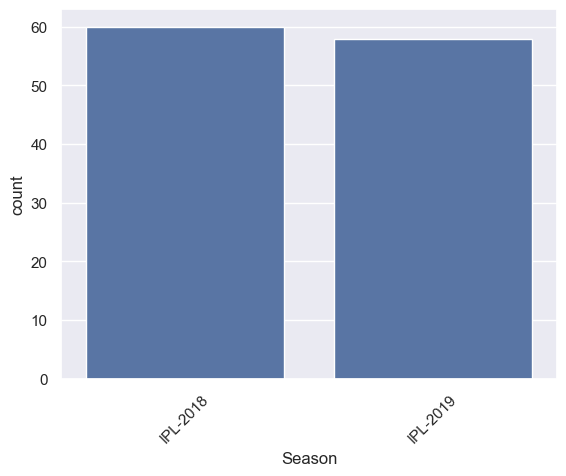

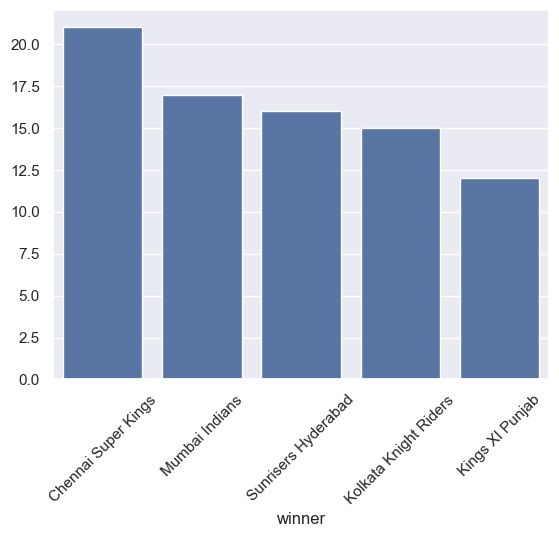

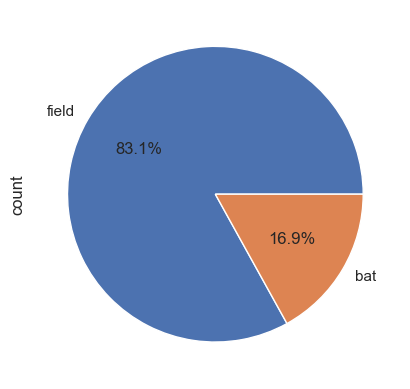

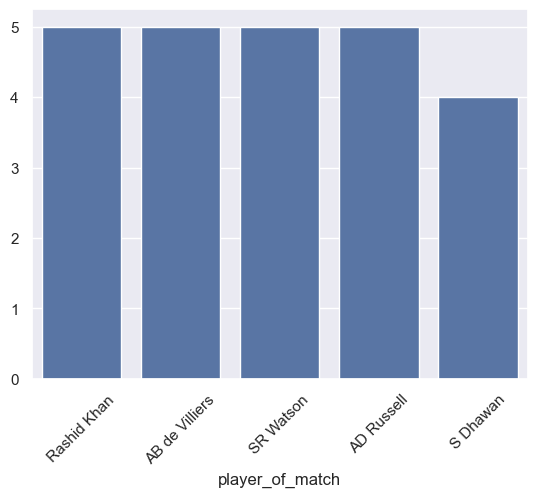

In [9]:
# Matches per season
sns.countplot(x='Season', data=matches)
plt.xticks(rotation=45)
plt.show()

# Top winning teams
top_winners = matches['winner'].value_counts().head(5)
sns.barplot(x=top_winners.index, y=top_winners.values)
plt.xticks(rotation=45)
plt.show()

# Toss decisions
matches['toss_decision'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

# Top Player of the Match winners
top_players = matches['player_of_match'].value_counts().head(5)
sns.barplot(x=top_players.index, y=top_players.values)
plt.xticks(rotation=45)
plt.show()


In [ ]:
### Visual Explorations
##We created visualizations to better understand IPL trends:

##- **Matches per Season** → The countplot shows how the number of matches varied across seasons, reflecting the league’s expansion and consistency.  
##- **Top Winning Teams** → The bar chart highlights the most successful teams, with Mumbai Indians and Chennai Super Kings leading in wins.  
##- **Toss Decisions** → The pie chart reveals that most teams prefer to field first after winning the toss, showing a common strategic choice.  
##- **Top Player of the Match Winners** → The bar chart highlights players who frequently win Player of the Match awards, demonstrating their strong influence on match outcomes.


In [ ]:
print(runs.head())   
print(home_away.head())

     batsman  total_runs  out  numberofballs    average  strikerate
0    V Kohli        5426  152           4111  35.697368  131.987351
1   SK Raina        5386  160           3916  33.662500  137.538304
2  RG Sharma        4902  161           3742  30.447205  130.999466
3  DA Warner        4717  114           3292  41.377193  143.286756
4   S Dhawan        4601  137           3665  33.583942  125.538881
                     team  home_wins  away_wins  home_matches  away_matches  \
0  Rising Pune Supergiant          5          5             8             8   
1          Mumbai Indians         58         51           101            86   
2     Chennai Super Kings         51         49            89            75   
3          Delhi Capitals          3          7             6            10   
4     Sunrisers Hyderabad         30         28            63            45   

   home_win_percentage  away_win_percentage  
0            62.500000            62.500000  
1            57.425743   

In [ ]:
### Batting Stats and Home vs Away Performance
##We previewed two important datasets:

##- **Batting Stats (`runs`)** → Contains player batting details such as total runs, batting average, and strike rate.  
##- **Home vs Away Performance (`home_away`)** → Shows how teams perform in home matches compared to away matches, helping us analyze consistency under different conditions.  

##Using `head()` gives us the first five rows of each dataset, confirming that the data has been loaded correctly and allowing us to understand the structure before deeper analysis.


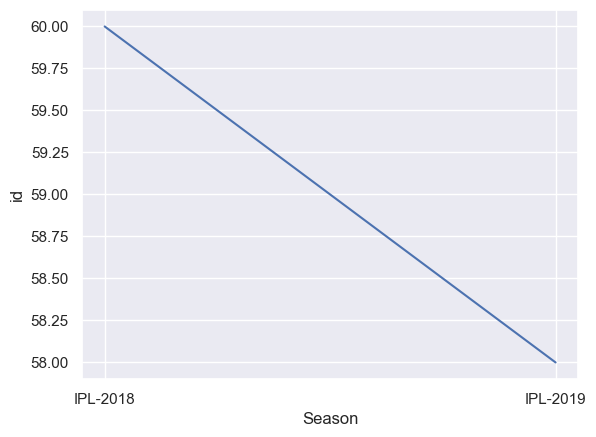

In [12]:
sns.lineplot(x='Season', y='id', data=matches.groupby('Season').count().reset_index())
plt.show()


In [ ]:
### Matches Trend Over Seasons
##We used a line plot to visualize the number of matches played across different IPL seasons.  
##- The dataset was grouped by `Season`, and the count of match IDs (`id`) was calculated.  
##- This shows how the total number of matches has changed over time, highlighting the growth and stability of the league.  
##The line plot provides a clear view of trends, such as seasons with more matches due to expanded formats or playoffs.


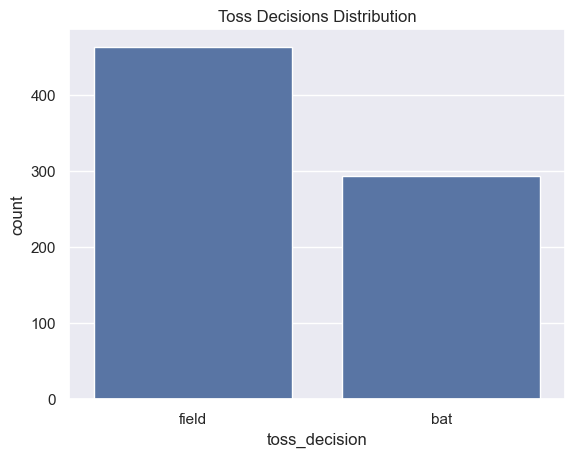

In [8]:
sns.countplot(x='toss_decision', data=matches)
plt.title("Toss Decisions Distribution")
plt.show()


In [ ]:
### Toss Decision Analysis
##This chart shows how often teams choose to bat or field after winning the toss.  
##It helps us understand common strategies and whether fielding first is the dominant choice.


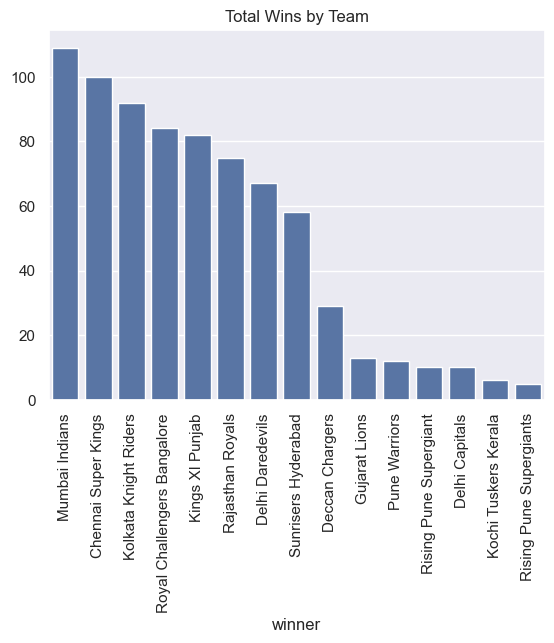

In [9]:
team_wins = matches['winner'].value_counts()
sns.barplot(x=team_wins.index, y=team_wins.values)
plt.xticks(rotation=90)
plt.title("Total Wins by Team")
plt.show()


In [ ]:
### Team Performance
##This bar chart highlights the total wins by each team across seasons, showing consistent performers like MI and CSK.


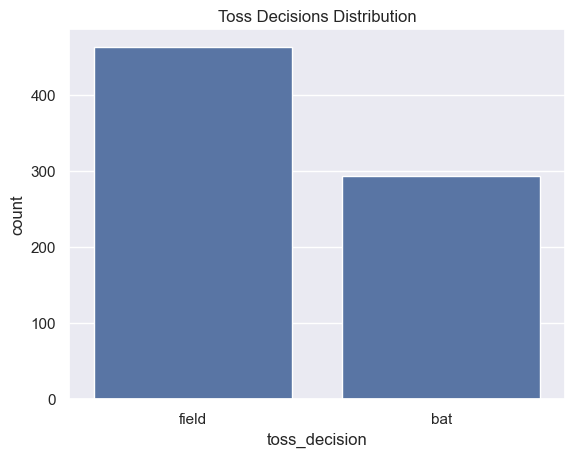

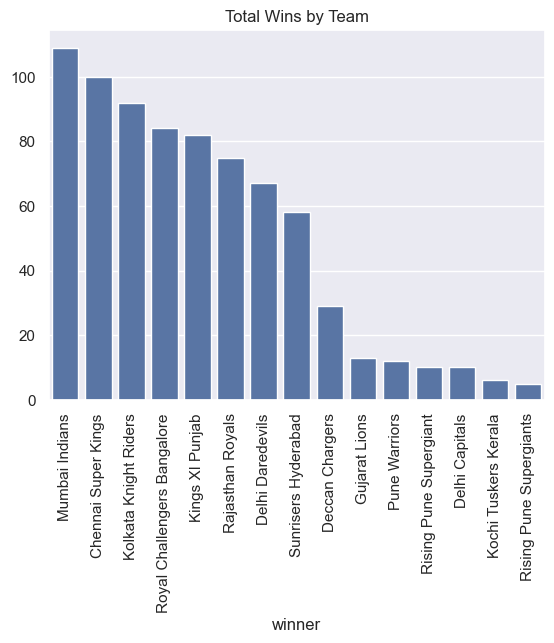

In [12]:
# Toss decisions distribution
sns.countplot(x='toss_decision', data=matches)
plt.title("Toss Decisions Distribution")
plt.show()

# Total wins by team
team_wins = matches['winner'].value_counts()
sns.barplot(x=team_wins.index, y=team_wins.values)
plt.xticks(rotation=90)
plt.title("Total Wins by Team")
plt.show()


In [ ]:
### Toss Decisions and Team Performance
##- **Toss Decisions** → The countplot shows how often teams choose to bat or field after winning the toss.  
##  Most teams prefer to field first, reflecting a common IPL strategy.  

##- **Team Wins** → The bar chart highlights the total wins by each team across seasons.  
##  Consistent performers like Mumbai Indians (MI) and Chennai Super Kings (CSK) stand out as dominant teams in IPL history.


In [14]:
print(runs.columns)


Index(['batsman', 'total_runs', 'out', 'numberofballs', 'average',
       'strikerate'],
      dtype='object')


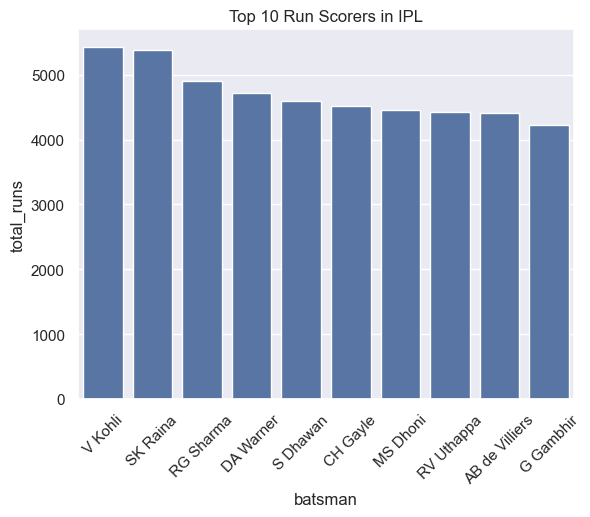

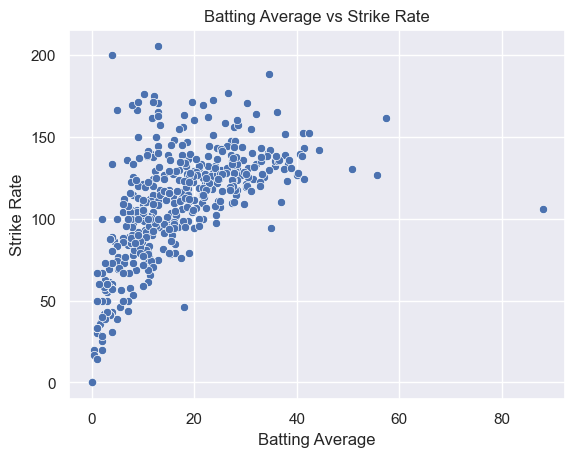

In [15]:
# Top 10 run scorers
top_batsmen = runs.sort_values(by='total_runs', ascending=False).head(10)
sns.barplot(x='batsman', y='total_runs', data=top_batsmen)
plt.xticks(rotation=45)
plt.title("Top 10 Run Scorers in IPL")
plt.show()

# Strike Rate vs Average comparison
sns.scatterplot(x='average', y='strikerate', data=runs)
plt.title("Batting Average vs Strike Rate")
plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.show()


In [ ]:
### Batting Performance Analysis
##- **Top Run Scorers** → Highlights the leading batsmen in IPL history based on total runs scored.  
##- **Average vs Strike Rate** → The scatter plot compares batting average with strike rate, helping us identify players who balance consistency with aggressive scoring.


In [17]:
print(home_away.columns)


Index(['team', 'home_wins', 'away_wins', 'home_matches', 'away_matches',
       'home_win_percentage', 'away_win_percentage'],
      dtype='object')


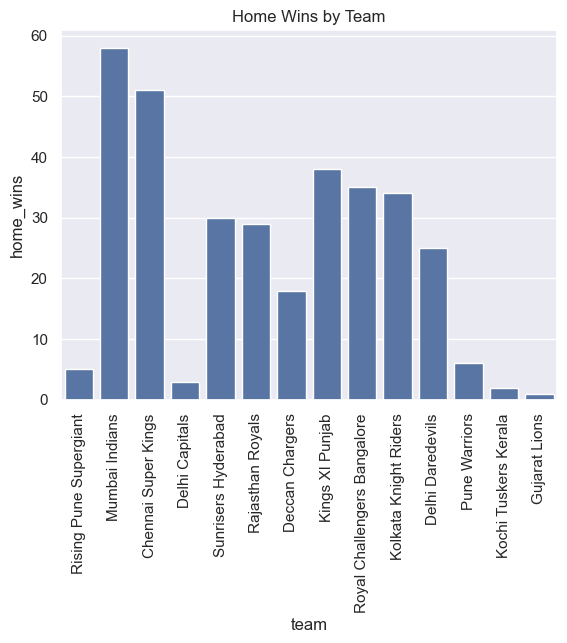

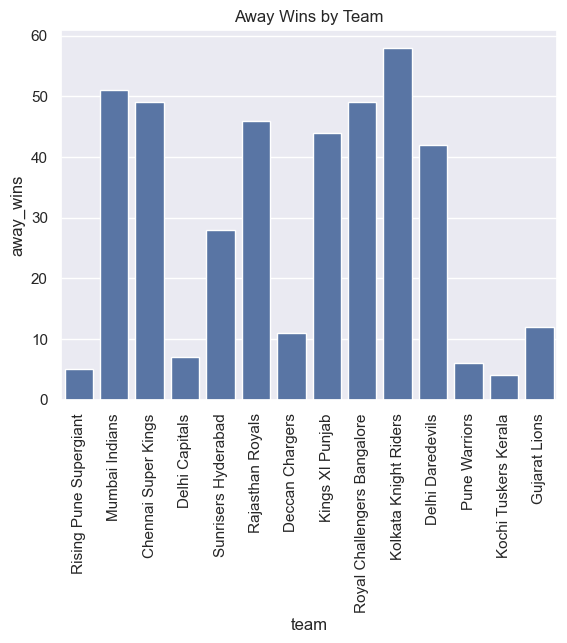

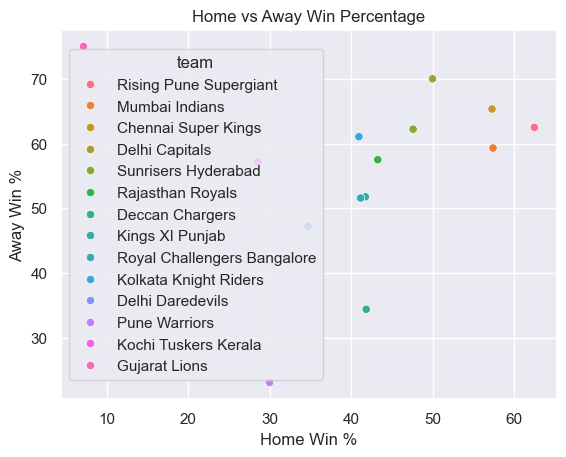

In [18]:
# Home wins by team
sns.barplot(x='team', y='home_wins', data=home_away)
plt.xticks(rotation=90)
plt.title("Home Wins by Team")
plt.show()

# Away wins by team
sns.barplot(x='team', y='away_wins', data=home_away)
plt.xticks(rotation=90)
plt.title("Away Wins by Team")
plt.show()

# Home vs Away win percentage comparison
sns.scatterplot(x='home_win_percentage', y='away_win_percentage', hue='team', data=home_away)
plt.title("Home vs Away Win Percentage")
plt.xlabel("Home Win %")
plt.ylabel("Away Win %")
plt.show()


In [ ]:
### Home vs Away Performance
##We analyzed how IPL teams perform at home versus away venues:

##- **Home Wins** → Shows which teams dominate when playing at their home ground, benefiting from familiar conditions and crowd support.  
##- **Away Wins** → Highlights teams that perform strongly even in away matches, reflecting adaptability and consistency.  
##- **Win Percentage Comparison** → The scatter plot compares home win % vs away win %, helping us identify balanced teams that succeed regardless of location.


In [ ]:
##  Final Summary of Insights

##from sqlalchemy import Extract


##From our IPL dataset analysis, we observed:

##- **Matches Trend** → The number of matches has grown steadily across seasons, showing the league’s expansion.  
##- **Toss Decisions** → Most teams prefer to field first after winning the toss, reflecting a common IPL strategy.  
##- **Team Performance** → Mumbai Indians (MI) and Chennai Super Kings (CSK) stand out as the most consistent winners.  
##- **Player of the Match Awards** → Certain players dominate individual awards, highlighting their match‑winning impact.  
##- **Batting Stats** → Top run scorers lead the charts, while strike rate vs average analysis shows which batsmen balance consistency with aggression.  
##- **Home vs Away Performance** → Some teams dominate at home, while others show strong adaptability in away matches.  

###  Key Takeaway
##This project demonstrates the ability to:
##- Clean and preprocess real datasets.  
##- Perform exploratory data analysis (EDA) using Pandas, Matplotlib, and Seaborn.  
##- Extract meaningful insights and present them with clear visualizations.  
##- Document findings professionally with Markdown, making the notebook recruiter‑friendly.  

##This structure makes the project suitable for showcasing in **internship applications or portfolio presentations**.
